In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
healthcare = pd.read_csv('healthcare.csv')

In [3]:
healthcare.head()

,PatientId,HeartDisease,InsurancePlan,PatientName,Gender,Age,NumChronicConditions,NumDependents,MedicalRecordNo,MedicalExpense,Ward,Region,Smoker,BMI,BloodPressure,Cholesterol,Glucose,Diagnosis
0,1,0,2,Patient_1,Male,53.0,1,1,MR100000,3159.50,NaN,South,No,29.4,124.6,195.2,108.1,Healthy
1,2,0,1,Patient_2,Female,NaN,1,1,MR100001,1037.19,C20,West,No,34.1,116.9,147.3,160.8,Diabetic
2,3,0,1,Patient_3,Female,NaN,1,1,MR100002,2446.50,NaN,North,Yes,26.8,94.9,200.2,101.6,Healthy
3,4,0,1,Patient_4,Male,63.0,2,1,MR100003,1780.78,NaN,East,No,29.8,119.6,115.5,113.7,Healthy
4,5,0,1,Patient_5,Female,17.0,0,0,MR100004,1481.11,E4,South,Yes,19.8,111.1,164.0,92.7,Healthy


In [4]:
admissions = pd.read_csv(r'admissions.csv')

In [5]:
admissions.head()

,year,month,admissions
0,2015,January,192
1,2015,February,201
2,2015,March,249
3,2015,April,244
4,2015,May,223


## 1. Scatterplot (Numerical - Numerical)

<Axes: xlabel='BMI', ylabel='BloodPressure'>

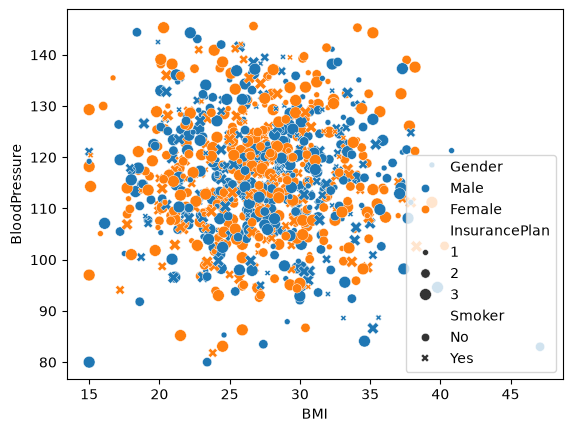

In [6]:
sns.scatterplot(x=healthcare['BMI'], y=healthcare['BloodPressure'],
                hue=healthcare['Gender'], style=healthcare['Smoker'], size=healthcare['InsurancePlan'])

## 2. Bar Plot (Numerical - Categorical)

In [7]:
healthcare.head()

,PatientId,HeartDisease,InsurancePlan,PatientName,Gender,Age,NumChronicConditions,NumDependents,MedicalRecordNo,MedicalExpense,Ward,Region,Smoker,BMI,BloodPressure,Cholesterol,Glucose,Diagnosis
0,1,0,2,Patient_1,Male,53.0,1,1,MR100000,3159.50,NaN,South,No,29.4,124.6,195.2,108.1,Healthy
1,2,0,1,Patient_2,Female,NaN,1,1,MR100001,1037.19,C20,West,No,34.1,116.9,147.3,160.8,Diabetic
2,3,0,1,Patient_3,Female,NaN,1,1,MR100002,2446.50,NaN,North,Yes,26.8,94.9,200.2,101.6,Healthy
3,4,0,1,Patient_4,Male,63.0,2,1,MR100003,1780.78,NaN,East,No,29.8,119.6,115.5,113.7,Healthy
4,5,0,1,Patient_5,Female,17.0,0,0,MR100004,1481.11,E4,South,Yes,19.8,111.1,164.0,92.7,Healthy


<Axes: xlabel='InsurancePlan', ylabel='Age'>

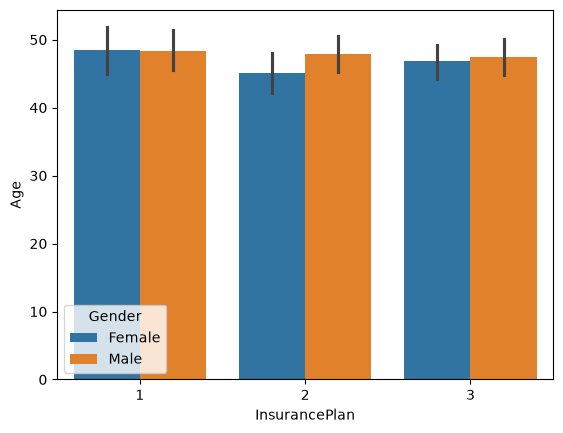

In [8]:
sns.barplot(x=healthcare['InsurancePlan'], y=healthcare['Age'], hue=healthcare['Gender'])

## 3. Box Plot (Numerical - Categorical)

<Axes: xlabel='Gender', ylabel='Age'>

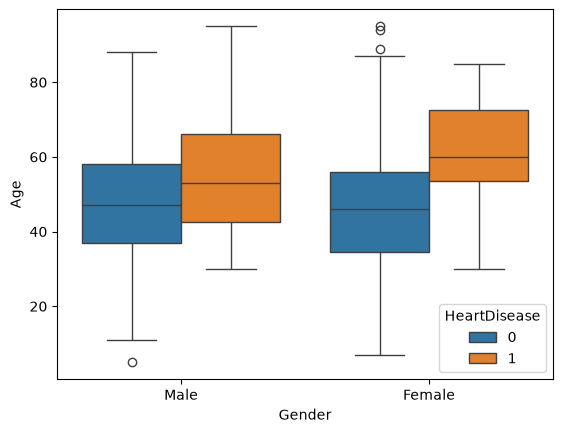

In [9]:
sns.boxplot(x=healthcare['Gender'], y=healthcare['Age'], hue=healthcare['HeartDisease'])

## 4. Distplot (Numerical - Categorical)

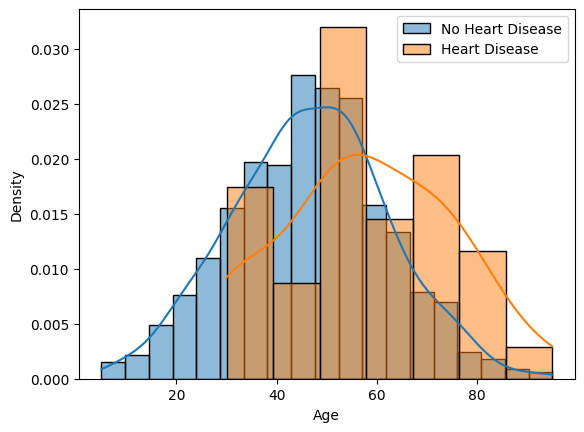

In [10]:
sns.histplot(healthcare[healthcare['HeartDisease']==0]['Age'], kde=True, stat='density', label='No Heart Disease')
sns.histplot(healthcare[healthcare['HeartDisease']==1]['Age'], kde=True, stat='density', label='Heart Disease')
plt.legend()

## 5. HeatMap (Categorical - Categorical)

In [11]:
healthcare.head(3)

,PatientId,HeartDisease,InsurancePlan,PatientName,Gender,Age,NumChronicConditions,NumDependents,MedicalRecordNo,MedicalExpense,Ward,Region,Smoker,BMI,BloodPressure,Cholesterol,Glucose,Diagnosis
0,1,0,2,Patient_1,Male,53.0,1,1,MR100000,3159.50,NaN,South,No,29.4,124.6,195.2,108.1,Healthy
1,2,0,1,Patient_2,Female,NaN,1,1,MR100001,1037.19,C20,West,No,34.1,116.9,147.3,160.8,Diabetic
2,3,0,1,Patient_3,Female,NaN,1,1,MR100002,2446.50,NaN,North,Yes,26.8,94.9,200.2,101.6,Healthy


<Axes: xlabel='HeartDisease', ylabel='InsurancePlan'>

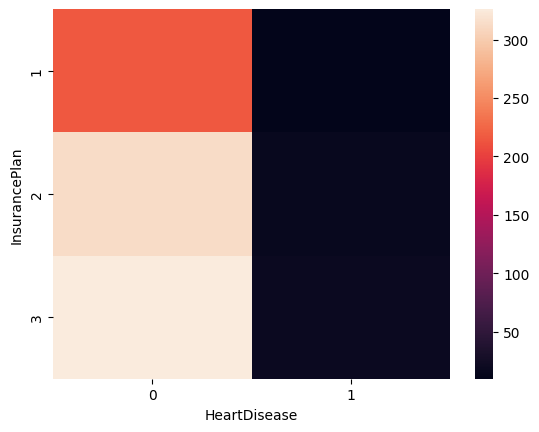

In [12]:
sns.heatmap(pd.crosstab(healthcare['InsurancePlan'], healthcare['HeartDisease']))

In [13]:
(healthcare.groupby('Region').mean(numeric_only=True)['HeartDisease'] * 100)

Region
East     6.726457
North    4.119850
South    5.309735
West     4.519774
Name: HeartDisease, dtype: float64

## 6. ClusterMap (Categorical - Categorical)

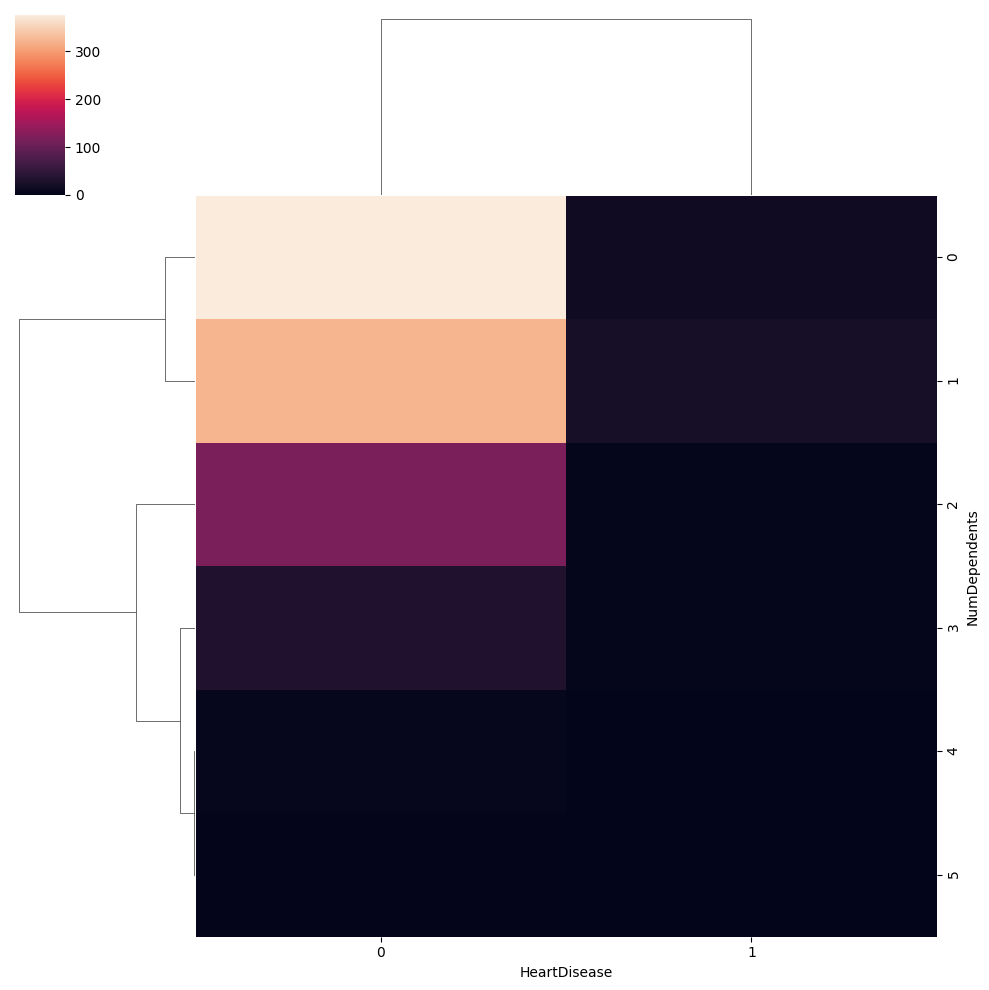

In [14]:
sns.clustermap(pd.crosstab(healthcare['NumDependents'], healthcare['HeartDisease']))

## 7. Pairplot

In [15]:
vitals = healthcare[['BMI', 'BloodPressure', 'Cholesterol', 'Glucose', 'Diagnosis']]
vitals.head()

,BMI,BloodPressure,Cholesterol,Glucose,Diagnosis
0,29.4,124.6,195.2,108.1,Healthy
1,34.1,116.9,147.3,160.8,Diabetic
2,26.8,94.9,200.2,101.6,Healthy
3,29.8,119.6,115.5,113.7,Healthy
4,19.8,111.1,164.0,92.7,Healthy


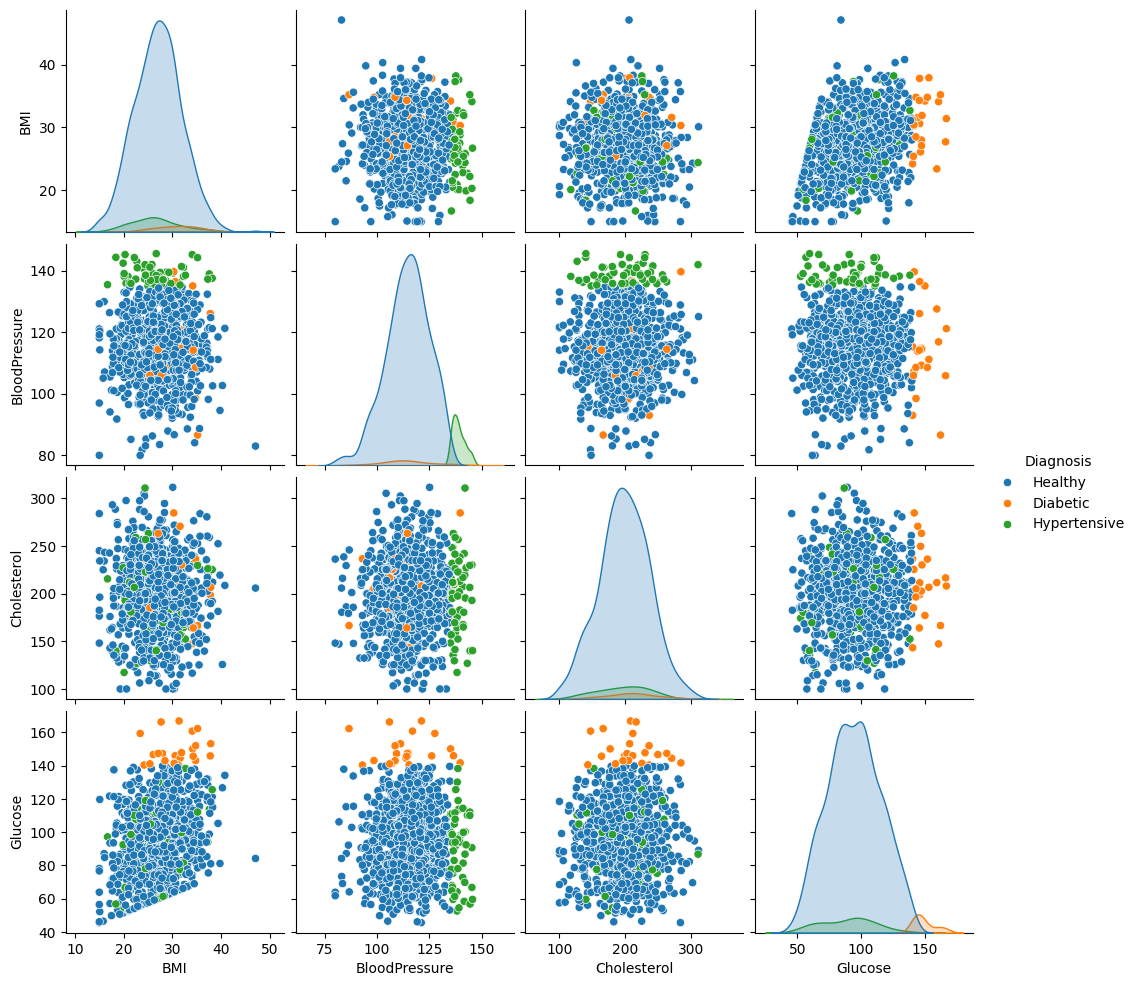

In [16]:
sns.pairplot(vitals, hue='Diagnosis')

## 8. Lineplot (Numerical - Numerical)

In [17]:
admissions.head()

,year,month,admissions
0,2015,January,192
1,2015,February,201
2,2015,March,249
3,2015,April,244
4,2015,May,223


In [18]:
new = admissions.groupby('year').sum(numeric_only=True).reset_index()

<Axes: xlabel='year', ylabel='admissions'>

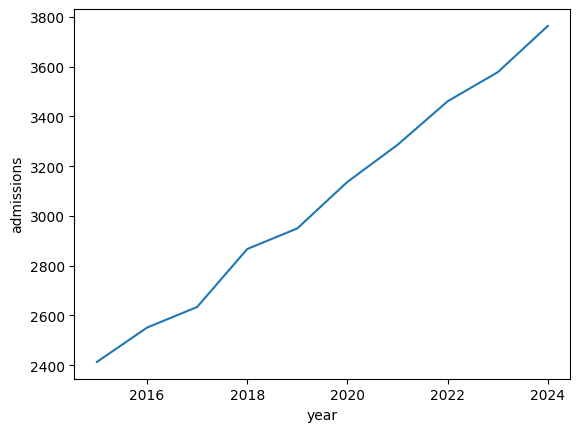

In [19]:
sns.lineplot(x=new['year'], y=new['admissions'])

In [20]:
admissions

,year,month,admissions
0,2015,January,192
1,2015,February,201
2,2015,March,249
3,2015,April,244
4,2015,May,223
...,...,...,...
115,2024,August,282
116,2024,September,258
117,2024,October,289
118,2024,November,282


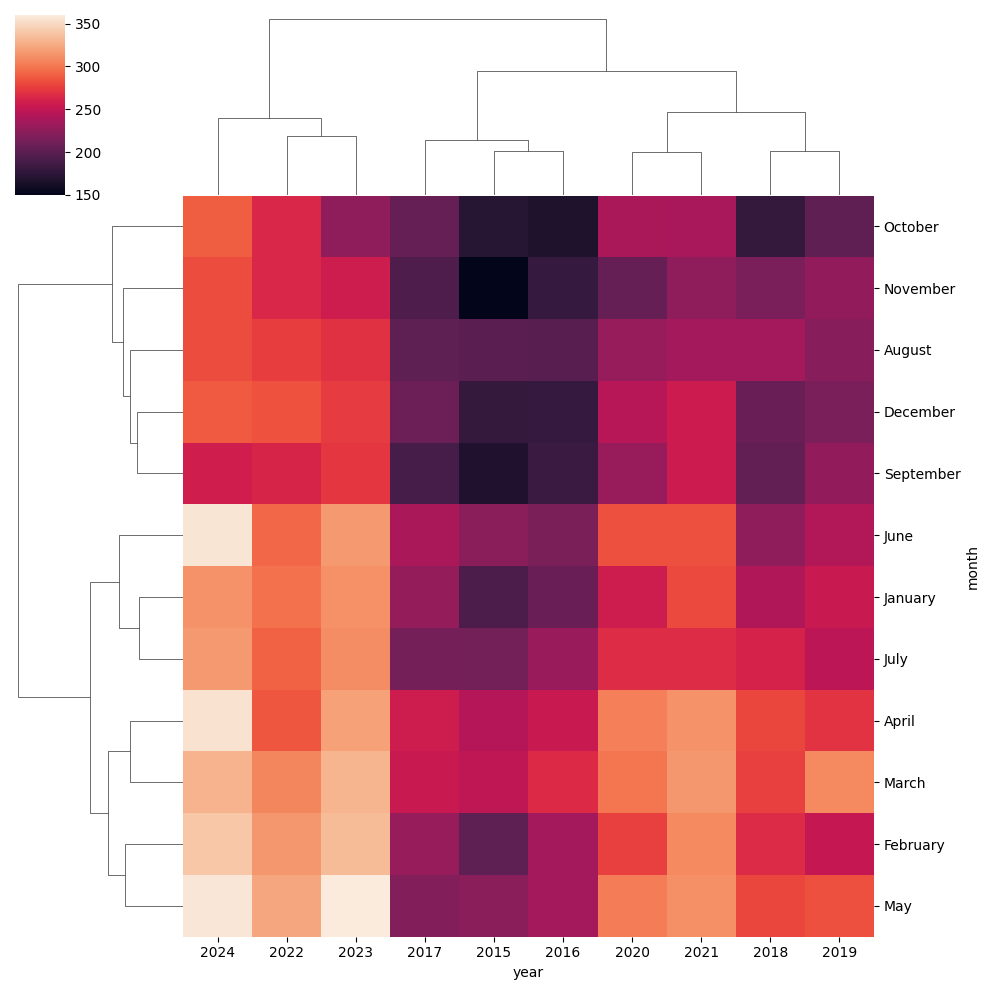

In [21]:
sns.clustermap(admissions.pivot_table(values='admissions', index='month', columns='year'))